In [1]:
import ccxt
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import os

In [2]:
def order_book_fetching():
    exchange = ccxt.binance({
        'enableRateLimit': True,
        'option':{'defaultType': 'future'}
    })
    
    symbol = 'BTC/USDT'
    timeframe = '1h'
    order_book = exchange.fetch_order_book(symbol)
    
    return order_book

In [3]:
def Collection(runtime_hours=3, batch_size=50):
    csv_filename = 'BTCUSDT_orderbook_v2.csv'

    memory_batch = []
    snapshot_counter = 1
    
    # Calculate loop boundaries
    start_time = time.time()
    end_time = start_time + (runtime_hours * 3600)
    
    print(f"🚀 Starting V2 Production Pipeline for {runtime_hours} hours...")
    print(f"Data will be flushed to {csv_filename} every {batch_size} snapshots.")
    
    while time.time() < end_time:
        loop_start = time.time()
        
        try:
            # --- Fetch and parse data from your original code ---
            order_book = order_book_fetching() 
            df_bids = pd.DataFrame(order_book['bids'], columns=['price', 'size'])
            df_asks = pd.DataFrame(order_book['asks'], columns=['price', 'size'])
            
            # Near-Touch 5-Level Imbalance
            top_n = 5
            top_bids_vol = df_bids['size'].iloc[:top_n].sum()
            top_asks_vol = df_asks['size'].iloc[:top_n].sum()
            imbalance = (top_bids_vol - top_asks_vol) / (top_bids_vol + top_asks_vol)

            P_bid, Q_bid = df_bids['price'].iloc[0], df_bids['size'].iloc[0]
            P_ask, Q_ask = df_asks['price'].iloc[0], df_asks['size'].iloc[0]
            mid_price = (P_bid * Q_bid + P_ask * Q_ask) / (Q_bid + Q_ask)
            
            spread = P_ask - P_bid
            timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

            snapshot_dict = {
                'snapshot': snapshot_counter,
                'timestamp': timestamp,
                'mid_price': mid_price,
                'spread': spread,
                'imbalance': imbalance
            }
            
            memory_batch.append(snapshot_dict)
            snapshot_counter += 1
            
            if len(memory_batch) >= batch_size:
                df_batch = pd.DataFrame(memory_batch)

                file_exists = os.path.isfile(csv_filename)
                df_batch.to_csv(csv_filename, mode='a', index=False, header=not file_exists)
                
                # Clear memory instantly
                memory_batch.clear()
                print(f"💾 [{timestamp}] Successfully flushed {batch_size} snapshots to disk. Memory cleared.")
                
        except Exception as e:
            print(f"⚠️ Error caught during snapshot processing: {e}")
            
        elapsed = time.time() - loop_start
        sleep_time = max(0, 5.0 - elapsed)
        time.sleep(sleep_time)

    if len(memory_batch) > 0:
        df_batch = pd.DataFrame(memory_batch)
        file_exists = os.path.isfile(csv_filename)
        df_batch.to_csv(csv_filename, mode='a', index=False, header=not file_exists)
        print(f"🏁 Loop complete. Finalized remaining {len(memory_batch)} trailing elements to disk.")

In [19]:
order_book_data = Collection(runtime_hours=3, batch_size=50) #Don't Run exepct you want to get new dataset

🚀 Starting data collection loop. Snapping order book every 5s...
Data will be saved in BTCUSDT_log_longhour.csv file
Progress: 20/♾️ snapshots recorded.
Progress: 40/♾️ snapshots recorded.
Progress: 60/♾️ snapshots recorded.
Progress: 80/♾️ snapshots recorded.
Progress: 100/♾️ snapshots recorded.
Progress: 120/♾️ snapshots recorded.
Progress: 140/♾️ snapshots recorded.
Progress: 160/♾️ snapshots recorded.
Progress: 180/♾️ snapshots recorded.
Progress: 200/♾️ snapshots recorded.
Progress: 220/♾️ snapshots recorded.
Progress: 240/♾️ snapshots recorded.
Progress: 260/♾️ snapshots recorded.
Progress: 280/♾️ snapshots recorded.
Progress: 300/♾️ snapshots recorded.
Progress: 320/♾️ snapshots recorded.
Progress: 340/♾️ snapshots recorded.
Progress: 360/♾️ snapshots recorded.
Progress: 380/♾️ snapshots recorded.
Progress: 400/♾️ snapshots recorded.
Progress: 420/♾️ snapshots recorded.
Progress: 440/♾️ snapshots recorded.
Progress: 460/♾️ snapshots recorded.
Progress: 480/♾️ snapshots recorded.

In [4]:
def read_data_logging():
    order_book = pd.read_csv('BTCUSDT_log_longhour.csv')
    return order_book
order_book = read_data_logging()

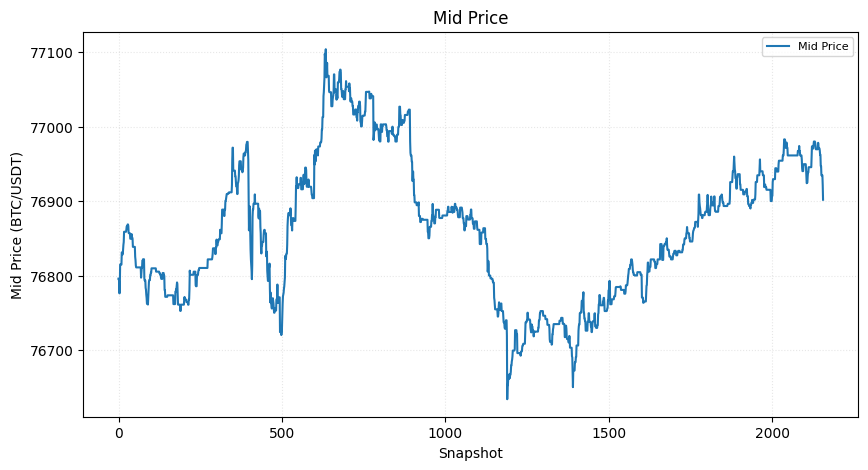

In [5]:
def plot_mid_price(order_book_data):
    plt.figure(figsize=(10, 5))
    
    plt.plot(order_book_data['snapshot'], order_book_data['mid_price'], label = 'Mid Price')
    plt.title('Mid Price')
    plt.xlabel('Snapshot')
    plt.ylabel('Mid Price (BTC/USDT)')
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.legend(loc='upper right', fontsize=8)
    
    plt.savefig('mid_price.png')
    plt.show()
plot_mid_price(order_book)

📈 --- Microstructure Lead-Lag Correlation Matrix ---
Correlation (Simultaneous) : 0.0237
Correlation (Imbalance -> 10s Future Price): -0.0136
📈 --- Microstructure Statistical Results ---
Mean Imbalance State: 0.0953
Imbalance Volatility (Std Dev): 0.4457


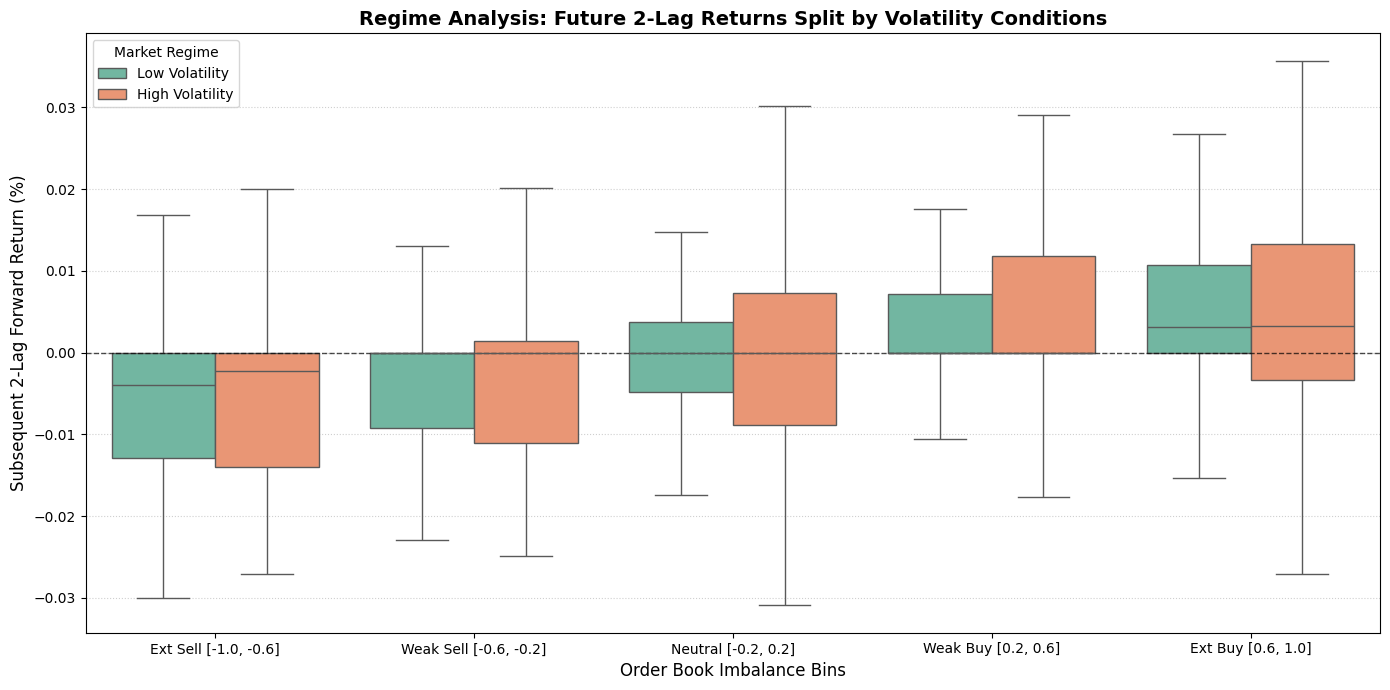

In [6]:
def mid_price_and_imbalance_exploration(order_book_data, verbose=True):
    order_book_data['midprice_roc'] = order_book_data['mid_price'].pct_change()
    order_book_data['imbalance_roc'] = order_book_data['imbalance'].pct_change()
       
    current_corr = order_book_data['imbalance_roc'].corr(order_book_data['midprice_roc'])
    future_corr = order_book_data['imbalance_roc'].corr(order_book_data['midprice_roc'].shift(-2))
    
    print("📈 --- Microstructure Lead-Lag Correlation Matrix ---")   
    print(f"Correlation (Simultaneous) : {current_corr:.4f}")
    print(f"Correlation (Imbalance -> 10s Future Price): {future_corr:.4f}")

    print("📈 --- Microstructure Statistical Results ---")
    print(f"Mean Imbalance State: {order_book_data['imbalance'].mean():.4f}")
    print(f"Imbalance Volatility (Std Dev): {order_book_data['imbalance'].std():.4f}")
    
#     --- Relationship between imblalance, future mid price and volatility.

    order_book_data['future_mid_price'] = order_book_data['mid_price'].shift(-3)
    order_book_data['future_return'] = ((order_book_data['future_mid_price'] - order_book_data['mid_price']) / order_book_data['mid_price']) * 100
    order_book_data['rolling_vol'] = order_book_data['mid_price'].pct_change().rolling(window=12).std()
    
    bin_edges = [-1, -0.6, -0.2, 0.2, 0.6, 1]
    bin_labels = ['Ext Sell [-1.0, -0.6]', 'Weak Sell [-0.6, -0.2]', 'Neutral [-0.2, 0.2]', 'Weak Buy [0.2, 0.6]', 'Ext Buy [0.6, 1.0]']
    order_book_data['imbalance_bin'] = pd.cut(order_book_data['imbalance'], bins=bin_edges, labels=bin_labels)    

    df_regime = order_book_data.dropna(subset=['rolling_vol', 'future_return', 'imbalance_bin']).copy()
    df_regime['vol_regime'] = pd.qcut(df_regime['rolling_vol'], q=2, labels=['Low Volatility', 'High Volatility'])

    plt.figure(figsize=(14, 7))
    sns.boxplot(
        data=df_regime, 
        x='imbalance_bin', 
        y='future_return', 
        hue='vol_regime',       # <-- This splits each bin into Low vs High vol bars!
        palette='Set2',         # Clean, distinct color palette for the regimes
        showfliers=False  
    )

    plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    plt.title('Regime Analysis: Future 2-Lag Returns Split by Volatility Conditions', fontsize=14, fontweight='bold')
    plt.xlabel('Order Book Imbalance Bins', fontsize=12)
    plt.ylabel('Subsequent 2-Lag Forward Return (%)', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend(title='Market Regime')
    plt.tight_layout()
    
    plt.savefig('Regime_Analysis.png')
    plt.show()

mid_price_and_imbalance_exploration(order_book)

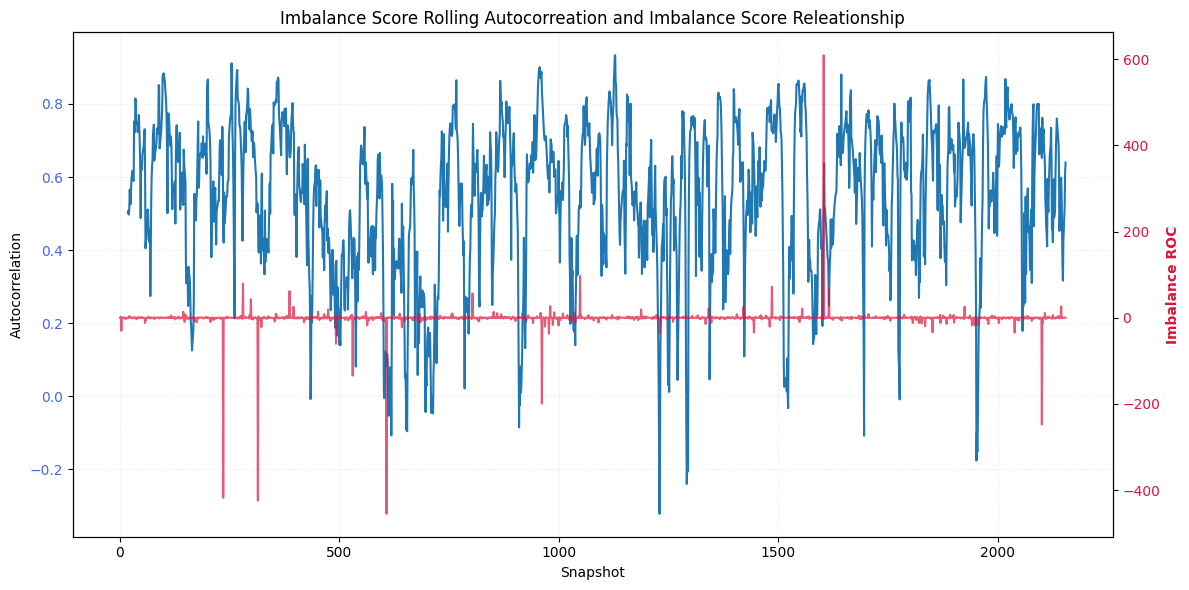

In [7]:
def calculate_rolling_autocorr(order_book_data, window=20):
    # .rolling().apply() lets us look at a small window of time moving forward
    order_book_data['rolling_corr'] = order_book_data['imbalance'].rolling(window=window).apply(lambda x: x.autocorr(lag=1))
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    color = 'royalblue'
    ax1.plot(order_book_data['snapshot'], order_book_data['rolling_corr'], label = 'Rolling Correlation (Window=20)')
    ax1.set_xlabel('Snapshot')
    ax1.set_ylabel('Autocorrelation')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle=':', alpha=0.3)
    
    ax2 = ax1.twinx()  
    
    color = 'crimson'
    ax2.set_ylabel('Imbalance ROC', color=color, fontweight='bold')
    ax2.plot(order_book_data['snapshot'], order_book_data['imbalance_roc'], color=color, alpha=0.7, lw=1.5, label='Imbalance ROC')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Imbalance Score Rolling Autocorreation and Imbalance Score Releationship')
    fig.tight_layout()
    
    plt.savefig('Imbalance_Score.png')
    plt.show()
calculate_rolling_autocorr(order_book, window=20)

💡 Hypothesis Proven: As volatility spikes, order book memory significantly drops (Negative Correlation).


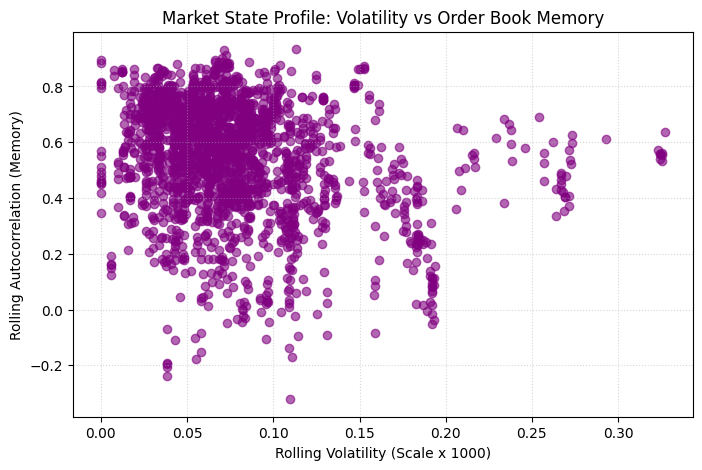

In [8]:
def test_volatility_interaction(order_book_data, window=20):
    order_book_data['rolling_vol'] = order_book_data['midprice_roc'].rolling(window=window).std()
    df_clean = order_book_data.dropna(subset=['rolling_vol', 'rolling_corr'])

    
    vol_vs_memory_corr = df_clean['rolling_vol'].corr(df_clean['rolling_corr'])
    
    if vol_vs_memory_corr < -0.2:
        print("💡 Hypothesis Proven: As volatility spikes, order book memory significantly drops (Negative Correlation).")
    else:
        print("💡 Regime Result: Volatility and memory do not share a strong linear inverse relationship in this sample.")
        
    # 4. Plot the relationship as a scatter plot to view regimes
    plt.figure(figsize=(8, 5))
    plt.scatter(df_clean['rolling_vol'] * 1000, df_clean['rolling_corr'], color='purple', alpha=0.6)
    plt.title('Market State Profile: Volatility vs Order Book Memory')
    plt.xlabel('Rolling Volatility (Scale x 1000)')
    plt.ylabel('Rolling Autocorrelation (Memory)')
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.savefig('Volatility_Order Book.png')
    plt.show()

test_volatility_interaction(order_book, window=20)

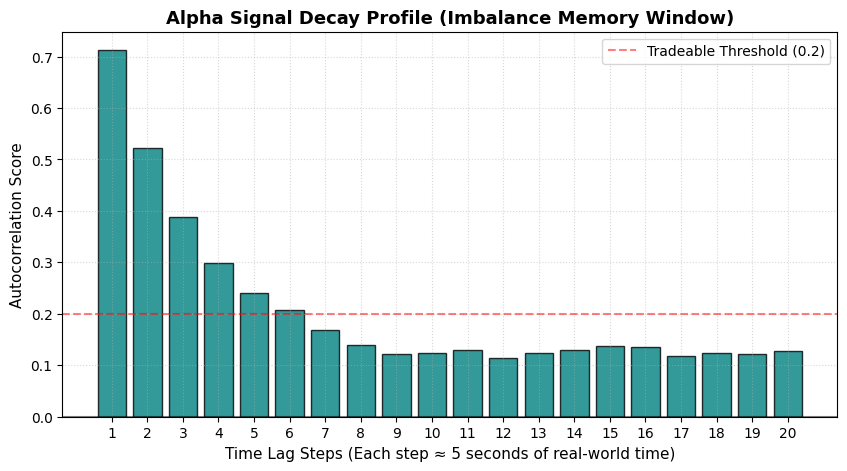

In [9]:
def plot_signal_decay_profile(order_book_data, max_lags=10):
    lags = list(range(1, max_lags + 1))
    autocorr_values = [order_book_data['imbalance'].autocorr(lag=l) for l in lags]
    
    plt.figure(figsize=(10, 5))
    plt.bar(lags, autocorr_values, color='teal', alpha=0.8, edgecolor='black')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Tradeable Threshold (0.2)')
    
    plt.title('Alpha Signal Decay Profile (Imbalance Memory Window)', fontsize=13, fontweight='bold')
    plt.xlabel('Time Lag Steps (Each step ≈ 5 seconds of real-world time)', fontsize=11)
    plt.ylabel('Autocorrelation Score', fontsize=11)
    plt.xticks(lags)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend()
    
    plt.savefig('Signal_Decay.png')
    plt.show()

plot_signal_decay_profile(order_book, max_lags=20)

⏱️ --- Extreme Imbalance (> 0.6) Run-Length Analysis ---
Total separate extreme streaks detected: 139
Average consecutive snapshots sustained: 2.42 snapshots (~12.1 seconds)
Longest single sustained streak: 14 snapshots (70 seconds)


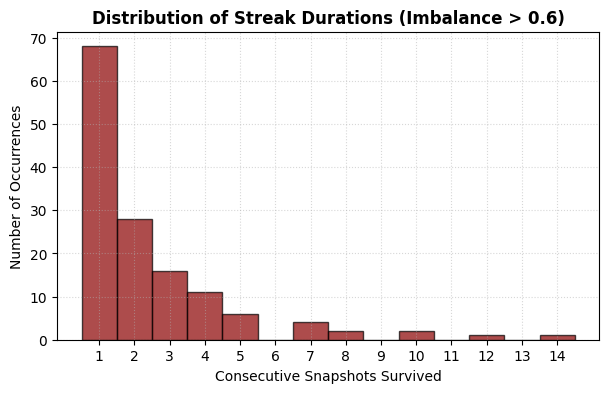

In [10]:
def streak_durations(order_book_data, threshold=0.5):    
        
    order_book_data['imb_threshold'] = order_book_data['imbalance'] > threshold
    order_book_data['streak_id'] = (order_book_data['imb_threshold'] != order_book_data['imb_threshold'].shift()).cumsum()

    streaks = order_book_data[order_book_data['imb_threshold'] == True]

    if len(streaks) == 0: 
        print('No streaks count')
        return
        
    streak_counts = streaks.groupby('streak_id').size()

    avg_snapshots = streak_counts.mean()
    max_snapshots = streak_counts.max()
    total_streaks = len(streak_counts)

    avg_seconds = avg_snapshots * 5
    
    
    
    print(f"⏱️ --- Extreme Imbalance (> {threshold}) Run-Length Analysis ---")
    print(f"Total separate extreme streaks detected: {total_streaks}")
    print(f"Average consecutive snapshots sustained: {avg_snapshots:.2f} snapshots (~{avg_seconds:.1f} seconds)")
    print(f"Longest single sustained streak: {max_snapshots} snapshots ({max_snapshots * 5} seconds)")
    
    # 6. Plot a distribution bar chart of the streak lengths
    plt.figure(figsize=(7, 4))
    plt.hist(streak_counts, bins=np.arange(1, max_snapshots + 2) - 0.5, color='darkred', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of Streak Durations (Imbalance > {threshold})', fontsize=12, fontweight='bold')
    plt.xlabel('Consecutive Snapshots Survived')
    plt.ylabel('Number of Occurrences')
    plt.xticks(range(1, max_snapshots + 1))
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.savefig('Streak_Durations.png')
    plt.show()
    
streak_durations(order_book, threshold=0.6)

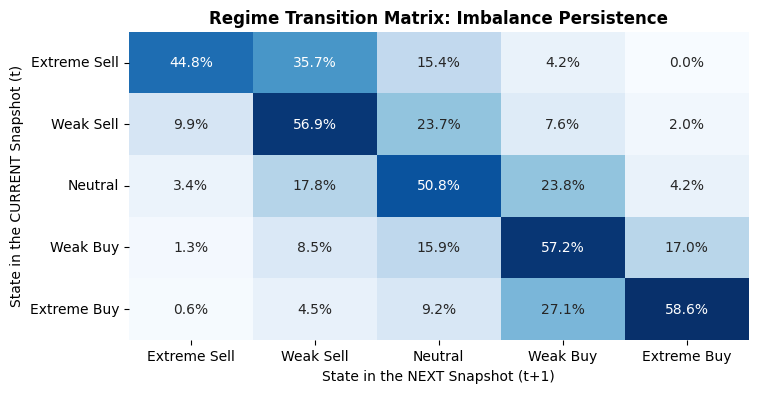

In [11]:
def test_imbalance_persistence(order_book_data):
    bins = [-1, -0.6, -0.2, 0.2, 0.6, 1]
    labels = ['Extreme Sell', 'Weak Sell', 'Neutral', 'Weak Buy', 'Extreme Buy']
    
    order_book_data['regime'] = pd.cut(order_book_data['imbalance'], bins=bins, labels=labels)
    order_book_data['next_regime'] = order_book_data['regime'].shift(-1)
    
    transition_matrix = pd.crosstab(order_book_data['regime'], order_book_data['next_regime'], normalize='index')
    
    plt.figure(figsize = (8, 4))
    sns.heatmap(transition_matrix, annot=True, cmap='Blues', fmt=".1%", cbar=False)
    plt.title('Regime Transition Matrix: Imbalance Persistence', fontweight='bold')
    plt.xlabel('State in the NEXT Snapshot (t+1)')
    plt.ylabel('State in the CURRENT Snapshot (t)')
    
    plt.savefig('Regime_Transition_Matrix.png')
    plt.show()
    
    
test_imbalance_persistence(order_book)

💸 --- Spread Interaction (Adverse Selection Cost) ---
Average Spread during Neutral Churn   : 0.01 USDT
Average Spread during Extreme Streaks : 0.01 USDT
Spread Expansion Factor               : +20.34%


<Figure size 600x500 with 0 Axes>

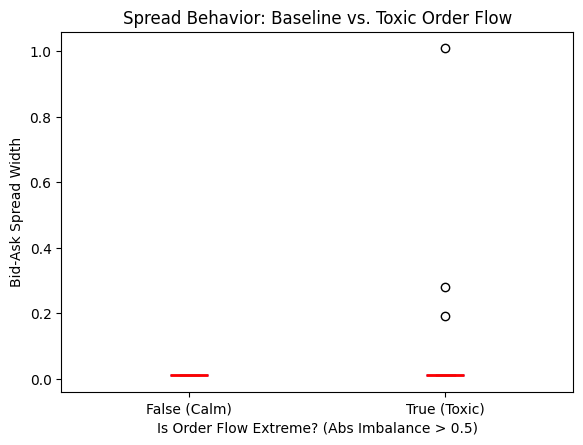

In [12]:
def test_spread_interaction(order_book_data, threshold=0.5):
    df = order_book_data.copy()

    df['is_extreme'] = df['imbalance'].abs() > threshold

    mean_baseline_spread = df[df['is_extreme'] == False]['spread'].mean()
    mean_extreme_spread = df[df['is_extreme'] == True]['spread'].mean()

    pct_increase = ((mean_extreme_spread - mean_baseline_spread) / mean_baseline_spread) * 100
    
    print("💸 --- Spread Interaction (Adverse Selection Cost) ---")
    print(f"Average Spread during Neutral Churn   : {mean_baseline_spread:.2f} USDT")
    print(f"Average Spread during Extreme Streaks : {mean_extreme_spread:.2f} USDT")
    print(f"Spread Expansion Factor               : +{pct_increase:.2f}%")

    plt.figure(figsize=(6, 5))
    df.boxplot(column='spread', by='is_extreme', grid=False, patch_artist=True,
               boxprops=dict(facecolor="lightblue", color="blue"),
               medianprops=dict(color="red", linewidth=2))
    
    plt.title('Spread Behavior: Baseline vs. Toxic Order Flow')
    plt.suptitle('')
    plt.xlabel('Is Order Flow Extreme? (Abs Imbalance > 0.5)')
    plt.ylabel('Bid-Ask Spread Width')
    plt.xticks([1, 2], ['False (Calm)', 'True (Toxic)'])
    
    plt.savefig('Toxic_Flow_Spread.png')
    plt.show()

test_spread_interaction(order_book, threshold=0.5)

In [13]:
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

In [14]:
def significant_testing(order_book_data):
    df_clean = order_book_data.dropna(subset=['future_return', 'imbalance', 'rolling_vol', 'imbalance_bin']).copy()

    ext_buy_signals = df_clean[df_clean['imbalance_bin'] == 'Ext Buy [0.6, 1.0]']['future_return']
    
    if len(ext_buy_signals) > 0:
        wilcox_stat, wilcox_p = stats.wilcoxon(ext_buy_signals, alternative='greater')
    else:
        wilcox_p = float('nan')

    # Mutual Information Score (Multi-Variable Dependency)
    # ---------------------------------------------------------
    df_features = df_clean[['imbalance', 'rolling_vol']].copy()
    target_return = df_clean['future_return']
    mi_scores = mutual_info_regression(df_features, target_return)

    # Print the Final Research Verdict
    print("🏆 ==================== FINAL RESEARCH VERDICT ====================")
    print("1️⃣ DIRECTIONAL CONSISTENCY TEST (Wilcoxon Rank):")
    print(f"    - P-Value: {wilcox_p:.20f}")
    if pd.isna(wilcox_p):
        print("    - Verdict: ERROR. No data found in the specified bin.")
    elif wilcox_p < 0.05:
        print("    - Verdict: STATISTICALLY SIGNIFICANT. The upward drift is a consistent market reality.")
    else:
        print("    - Verdict: NOT SIGNIFICANT. The drift could be an isolated sampling fluke.")
    print("-" * 67)
    print("2️⃣ RELATIONSHIP STRENGTH MODEL (Mutual Information):")
    print(f"    - Imbalance -> Future Return Information Link:  {mi_scores[0]:.4f}")
    print(f"    - Volatility -> Future Return Information Link: {mi_scores[1]:.4f}")
    print("===================================================================\n")

significant_testing(order_book)

🏆 ==================== FINAL RESEARCH VERDICT ====================
1️⃣ DIRECTIONAL CONSISTENCY TEST (Wilcoxon Rank):
    - P-Value: 0.00000000010372765054
    - Verdict: STATISTICALLY SIGNIFICANT. The upward drift is a consistent market reality.
-------------------------------------------------------------------
2️⃣ RELATIONSHIP STRENGTH MODEL (Mutual Information):
    - Imbalance -> Future Return Information Link:  0.0759
    - Volatility -> Future Return Information Link: 0.3024



In [18]:
backtest_dataset = Collection(runtime_hours=3, batch_size=100) #Don't Run exepct you want to get new dataset

🚀 Starting V2 Production Pipeline for 3 hours...
Data will be flushed to BTCUSDT_orderbook_v2.csv every 100 snapshots.
💾 [2026-05-22 17:32:49] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 17:41:10] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 17:49:31] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 17:57:51] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 18:06:12] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 18:14:33] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 18:22:54] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 18:31:15] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 18:39:36] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 18:47:56] Successfully flushed 100 snapshots to disk. Memory cleared.
💾 [2026-05-22 18:56:17] Successfully flus

In [22]:
def backtesting_csv():
    order_book = pd.read_csv('BTCUSDT_orderbook_v2.csv')
    return order_book
backtesting = backtesting_csv()

In [23]:
def run_imbalance_backtest(order_book_data, fee_percentage=0.0002):
    """
    Simulates a strategy trading extreme imbalances.
    fee_percentage: 0.02% (0.0002) represents a competitive VIP tier taker fee.
    """
    df_bt = order_book_data.copy()

    df_bt['buy_signal'] = df_bt['imbalance'] > 0.6
    df_bt['sell_signal'] = df_bt['imbalance'] < -0.6
    
    # This means our return is captured from t+1 to t+3 (the 2-lag horizon)
    df_bt['entry_price'] = df_bt['mid_price'].shift(-1)
    df_bt['exit_price'] = df_bt['mid_price'].shift(-4) 
    
    df_bt['raw_trade_return_pct'] = ((df_bt['exit_price'] - df_bt['entry_price']) / df_bt['entry_price']) * 100

    df_bt['strategy_return'] = np.nan
    df_bt.loc[df_bt['buy_signal'], 'strategy_return'] = df_bt['raw_trade_return_pct']
    df_bt.loc[df_bt['sell_signal'], 'strategy_return'] = -df_bt['raw_trade_return_pct']
    
    active_trades = df_bt.dropna(subset=['strategy_return']).copy()
    
    if len(active_trades) == 0:
        print("❌ No trades triggered with the current threshold.")
        return None
    # fee_percentage * 100 converts it to a percentage to match our return units
    round_trip_fee_pct = (fee_percentage * 2) * 100
    active_trades['net_trade_return'] = active_trades['strategy_return'] - round_trip_fee_pct

    total_trades = len(active_trades)
    win_rate = (active_trades['net_trade_return'] > 0).sum() / total_trades
    gross_pnl = active_trades['strategy_return'].sum()
    net_pnl = active_trades['net_trade_return'].sum()
    
    print("📊 ==================== BACKTEST RESULTS ====================")
    print(f"Total Trades Triggered: {total_trades}")
    print(f"Win Rate (Post-Fee):    {win_rate:.2%}")
    print(f"Gross PnL (No Fees):    {gross_pnl:.4f}%")
    print(f"Net PnL (After Fees):    {net_pnl:.4f}%")
    print("============================================================\n")
    
    return active_trades
trade_log = run_imbalance_backtest(backtesting, fee_percentage=0.0002)

📊 ==================== BACKTEST RESULTS ====================
Total Trades Triggered: 2511
Win Rate (Post-Fee):    2.19%
Gross PnL (No Fees):    6.1804%
Net PnL (After Fees):    -94.2596%



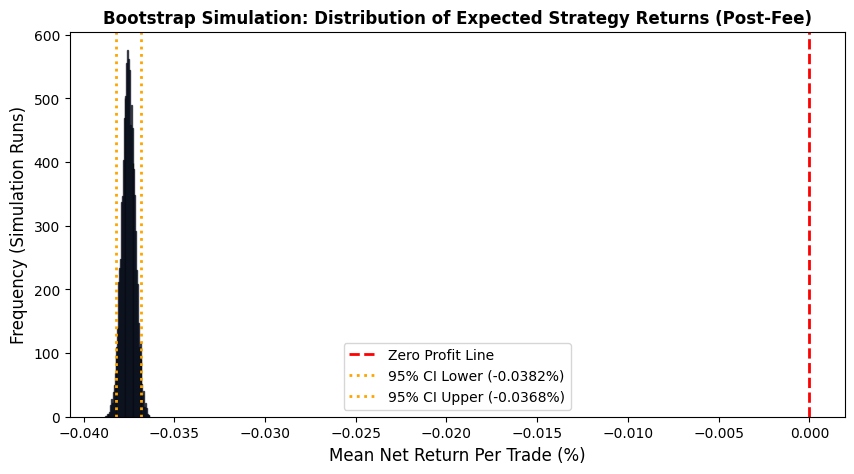

📊 ==================== BOOTSTRAP RESULTS ====================
95% Confidence Interval for Net Edge: [-0.0382%, -0.0368%]
Probability of Strategy Profitability: 0.00%



In [24]:
def bootstrap_strategy(active_trades, n_iterations=10000):
    returns = active_trades['net_trade_return'].values
    n_samples = len(returns)
    
    bootstrapped_means = []
    
    for _ in range(n_iterations):
        sample = np.random.choice(returns, size=n_samples, replace=True)
        bootstrapped_means.append(np.mean(sample))
        
    bootstrapped_means = np.array(bootstrapped_means)
    
    # Calculate the 95% Confidence Interval (2.5th percentile to 97.5th percentile)
    ci_lower = np.percentile(bootstrapped_means, 2.5)
    ci_upper = np.percentile(bootstrapped_means, 97.5)
    probability_profitable = (bootstrapped_means > 0).sum() / n_iterations
    
    # Plot the Bootstrap Distribution
    plt.figure(figsize=(10, 5))
    plt.hist(bootstrapped_means, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Profit Line')
    plt.axvline(ci_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI Lower ({ci_lower:.4f}%)')
    plt.axvline(ci_upper, color='orange', linestyle=':', linewidth=2, label=f'95% CI Upper ({ci_upper:.4f}%)')
    
    plt.title('Bootstrap Simulation: Distribution of Expected Strategy Returns (Post-Fee)', fontweight='bold')
    plt.xlabel('Mean Net Return Per Trade (%)', fontsize=12)
    plt.ylabel('Frequency (Simulation Runs)', fontsize=12)
    plt.legend()
    
    plt.savefig('Bootstrap.png')
    plt.show()
    
    print("📊 ==================== BOOTSTRAP RESULTS ====================")
    print(f"95% Confidence Interval for Net Edge: [{ci_lower:.4f}%, {ci_upper:.4f}%]")
    print(f"Probability of Strategy Profitability: {probability_profitable:.2%}")
    print("============================================================\n")

bootstrap_strategy(trade_log)